In [4]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression


In [4]:
df=pd.read_csv("crop prediction.csv")
print(df)

         Crop  Nitrogen  Phosphorus  Potassium  Temperature  Humidity   pH  \
0        Rice      40.0        20.0       15.0         18.0      45.0  5.5   
1       Wheat      41.0        21.0       16.0         18.8      46.0  5.6   
2       Maize      42.0        22.0       17.0         19.6      47.0  5.7   
3      Cotton      43.0        23.0       18.0         20.4      48.0  5.8   
4   Sugarcane      44.0        24.0       19.0         21.2      49.0  5.9   
..        ...       ...         ...        ...          ...       ...  ...   
95      Maize      50.0        30.0       25.0         26.0      55.0  6.5   
96  Sugarcane      60.0        40.0       35.0         18.0      65.0  5.5   
97      Wheat      87.0        27.0       32.0         31.6      52.0  7.2   
98      Maize      88.0        28.0       33.0         32.4      53.0  7.3   
99     Cotton      89.0        29.0       34.0         33.2      54.0  7.4   

    Rainfall SoilType Region Fertilizer  Yield Target  
0      

In [2]:
df.head()

,Crop,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH,Rainfall,SoilType,Region,Fertilizer,Yield,Target
0,Rice,40.0,20.0,15.0,18.0,45.0,5.5,60.0,Clay,North,No,2.5,Poor
1,Wheat,41.0,21.0,16.0,18.8,46.0,5.6,61.0,Loam,South,Yes,2.7,Good
2,Maize,42.0,22.0,17.0,19.6,47.0,5.7,62.0,Sandy,East,Yes,2.9,Poor
3,Cotton,43.0,23.0,18.0,20.4,48.0,5.8,63.0,Silty,West,No,3.1,Good
4,Sugarcane,44.0,24.0,19.0,21.2,49.0,5.9,64.0,Clay,North,Yes,3.3,Poor


In [3]:
df.tail()


,Crop,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH,Rainfall,SoilType,Region,Fertilizer,Yield,Target
95,Maize,50.0,30.0,25.0,26.0,55.0,6.5,70.0,Sandy,East,Yes,4.5,Poor
96,Sugarcane,60.0,40.0,35.0,18.0,65.0,5.5,80.0,Clay,NaN,Yes,6.5,Poor
97,Wheat,87.0,27.0,32.0,31.6,52.0,7.2,157.0,Loam,South,Yes,3.9,Good
98,Maize,88.0,28.0,33.0,32.4,53.0,7.3,158.0,Sandy,East,Yes,4.1,Poor
99,Cotton,89.0,29.0,34.0,33.2,54.0,7.4,159.0,Silty,West,No,4.3,Good


In [4]:
print(df.columns)

Index(['Crop', 'Nitrogen', 'Phosphorus', 'Potassium', 'Temperature',
       'Humidity', 'pH', 'Rainfall', 'SoilType', 'Region', 'Fertilizer',
       'Yield', 'Target'],
      dtype='str')


In [5]:
print(df.index)
print(df.shape)
print(df.info())

RangeIndex(start=0, stop=100, step=1)
(100, 13)
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Crop         99 non-null     str    
 1   Nitrogen     99 non-null     float64
 2   Phosphorus   99 non-null     float64
 3   Potassium    99 non-null     float64
 4   Temperature  99 non-null     float64
 5   Humidity     99 non-null     float64
 6   pH           99 non-null     float64
 7   Rainfall     99 non-null     float64
 8   SoilType     99 non-null     str    
 9   Region       98 non-null     str    
 10  Fertilizer   99 non-null     str    
 11  Yield        99 non-null     float64
 12  Target       100 non-null    str    
dtypes: float64(8), str(5)
memory usage: 8.3 KB
None


In [6]:
print(df.describe())

        Nitrogen  Phosphorus  Potassium  Temperature   Humidity         pH  \
count  99.000000   99.000000  99.000000    99.000000  99.000000  99.000000   
mean   64.080808   33.797980  32.464646    25.442424  65.242424   6.427273   
std    14.205257    8.766797  11.505379     4.668197  13.285784   0.583413   
min    40.000000   20.000000  15.000000    18.000000  45.000000   5.500000   
25%    52.000000   26.500000  23.000000    21.200000  53.500000   5.900000   
50%    64.000000   33.000000  31.000000    25.200000  65.000000   6.400000   
75%    76.000000   41.000000  42.000000    29.200000  76.500000   6.900000   
max    89.000000   49.000000  54.000000    33.200000  89.000000   7.400000   

         Rainfall      Yield  
count   99.000000  99.000000  
mean   108.252525   5.221212  
std     28.564765   1.758668  
min     60.000000   2.500000  
25%     83.500000   3.700000  
50%    108.000000   5.100000  
75%    132.500000   6.700000  
max    159.000000   8.300000  


In [7]:
print(df[["Temperature","Humidity"]])   

    Temperature  Humidity
0          18.0      45.0
1          18.8      46.0
2          19.6      47.0
3          20.4      48.0
4          21.2      49.0
..          ...       ...
95         26.0      55.0
96         18.0      65.0
97         31.6      52.0
98         32.4      53.0
99         33.2      54.0

[100 rows x 2 columns]


In [8]:
print(df.loc[2])

Crop           Maize
Nitrogen        42.0
Phosphorus      22.0
Potassium       17.0
Temperature     19.6
Humidity        47.0
pH               5.7
Rainfall        62.0
SoilType       Sandy
Region          East
Fertilizer       Yes
Yield            2.9
Target          Poor
Name: 2, dtype: object


In [9]:
print(df.iloc[2])

Crop           Maize
Nitrogen        42.0
Phosphorus      22.0
Potassium       17.0
Temperature     19.6
Humidity        47.0
pH               5.7
Rainfall        62.0
SoilType       Sandy
Region          East
Fertilizer       Yes
Yield            2.9
Target          Poor
Name: 2, dtype: object


In [10]:
#Check Missing Values
print(df.isnull())
#Count Missing
print(df.isnull().sum())

     Crop  Nitrogen  Phosphorus  Potassium  Temperature  Humidity     pH  \
0   False     False       False      False        False     False  False   
1   False     False       False      False        False     False  False   
2   False     False       False      False        False     False  False   
3   False     False       False      False        False     False  False   
4   False     False       False      False        False     False  False   
..    ...       ...         ...        ...          ...       ...    ...   
95  False     False       False      False        False     False  False   
96  False     False       False      False        False     False  False   
97  False     False       False      False        False     False  False   
98  False     False       False      False        False     False  False   
99  False     False       False      False        False     False  False   

    Rainfall  SoilType  Region  Fertilizer  Yield  Target  
0      False     False   Fa

In [12]:
#Fill Missing
df.fillna(0)

,Crop,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH,Rainfall,SoilType,Region,Fertilizer,Yield,Target
0,Rice,40.0,20.0,15.0,18.0,45.0,5.5,60.0,Clay,North,No,2.5,Poor
1,Wheat,41.0,21.0,16.0,18.8,46.0,5.6,61.0,Loam,South,Yes,2.7,Good
2,Maize,42.0,22.0,17.0,19.6,47.0,5.7,62.0,Sandy,East,Yes,2.9,Poor
3,Cotton,43.0,23.0,18.0,20.4,48.0,5.8,63.0,Silty,West,No,3.1,Good
4,Sugarcane,44.0,24.0,19.0,21.2,49.0,5.9,64.0,Clay,North,Yes,3.3,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Maize,50.0,30.0,25.0,26.0,55.0,6.5,70.0,Sandy,East,Yes,4.5,Poor
96,Sugarcane,60.0,40.0,35.0,18.0,65.0,5.5,80.0,Clay,0,Yes,6.5,Poor
97,Wheat,87.0,27.0,32.0,31.6,52.0,7.2,157.0,Loam,South,Yes,3.9,Good
98,Maize,88.0,28.0,33.0,32.4,53.0,7.3,158.0,Sandy,East,Yes,4.1,Poor


In [13]:
#Drop Missing
df.dropna()

,Crop,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH,Rainfall,SoilType,Region,Fertilizer,Yield,Target
0,Rice,40.0,20.0,15.0,18.0,45.0,5.5,60.0,Clay,North,No,2.5,Poor
1,Wheat,41.0,21.0,16.0,18.8,46.0,5.6,61.0,Loam,South,Yes,2.7,Good
2,Maize,42.0,22.0,17.0,19.6,47.0,5.7,62.0,Sandy,East,Yes,2.9,Poor
3,Cotton,43.0,23.0,18.0,20.4,48.0,5.8,63.0,Silty,West,No,3.1,Good
4,Sugarcane,44.0,24.0,19.0,21.2,49.0,5.9,64.0,Clay,North,Yes,3.3,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,Barley,84.0,24.0,29.0,29.2,49.0,6.9,154.0,Sandy,East,Yes,3.3,Poor
95,Maize,50.0,30.0,25.0,26.0,55.0,6.5,70.0,Sandy,East,Yes,4.5,Poor
97,Wheat,87.0,27.0,32.0,31.6,52.0,7.2,157.0,Loam,South,Yes,3.9,Good
98,Maize,88.0,28.0,33.0,32.4,53.0,7.3,158.0,Sandy,East,Yes,4.1,Poor


In [14]:
#Duplicates
df.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
95     True
96     True
97    False
98    False
99    False
Length: 100, dtype: bool

In [15]:
#Remove duplicates
df.drop_duplicates()

,Crop,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH,Rainfall,SoilType,Region,Fertilizer,Yield,Target
0,Rice,40.0,20.0,15.0,18.0,45.0,5.5,60.0,Clay,North,No,2.5,Poor
1,Wheat,41.0,21.0,16.0,18.8,46.0,5.6,61.0,Loam,South,Yes,2.7,Good
2,Maize,42.0,22.0,17.0,19.6,47.0,5.7,62.0,Sandy,East,Yes,2.9,Poor
3,Cotton,43.0,23.0,18.0,20.4,48.0,5.8,63.0,Silty,West,No,3.1,Good
4,Sugarcane,44.0,24.0,19.0,21.2,49.0,5.9,64.0,Clay,North,Yes,3.3,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,Millet,83.0,23.0,28.0,28.4,48.0,6.8,153.0,Loam,South,No,3.1,Good
94,Barley,84.0,24.0,29.0,29.2,49.0,6.9,154.0,Sandy,East,Yes,3.3,Poor
97,Wheat,87.0,27.0,32.0,31.6,52.0,7.2,157.0,Loam,South,Yes,3.9,Good
98,Maize,88.0,28.0,33.0,32.4,53.0,7.3,158.0,Sandy,East,Yes,4.1,Poor


In [17]:
#filtering data
#pH above 7.0
df[df["pH"]>7.0]

,Crop,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH,Rainfall,SoilType,Region,Fertilizer,Yield,Target
16,Rice,56.0,36.0,31.0,30.8,61.0,7.1,76.0,Clay,North,Yes,5.7,Poor
17,Wheat,57.0,37.0,32.0,31.6,62.0,7.2,77.0,Loam,South,Yes,5.9,Good
18,Maize,58.0,38.0,33.0,32.4,63.0,7.3,78.0,Sandy,East,No,6.1,Poor
19,Cotton,59.0,39.0,34.0,33.2,64.0,7.4,79.0,Silty,West,Yes,6.3,Good
36,Sugarcane,76.0,26.0,51.0,30.8,81.0,7.1,96.0,Clay,North,No,3.7,Poor
37,Millet,77.0,27.0,52.0,31.6,82.0,7.2,97.0,Loam,South,Yes,3.9,Good
38,Barley,78.0,28.0,53.0,32.4,83.0,7.3,98.0,Sandy,East,Yes,4.1,Poor
39,Soybean,79.0,29.0,54.0,33.2,84.0,7.4,99.0,Silty,West,No,4.3,Good
56,Rice,46.0,46.0,31.0,30.8,56.0,7.1,116.0,Clay,North,Yes,7.7,Poor
57,Wheat,47.0,47.0,32.0,31.6,57.0,7.2,117.0,Loam,South,No,7.9,Good


In [18]:
#Ascending
df.sort_values("Yield")

,Crop,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH,Rainfall,SoilType,Region,Fertilizer,Yield,Target
0,Rice,40.0,20.0,15.0,18.0,45.0,5.5,60.0,Clay,North,No,2.5,Poor
90,Maize,80.0,20.0,25.0,26.0,45.0,6.5,150.0,NaN,East,No,2.5,Poor
30,Barley,70.0,20.0,45.0,26.0,75.0,6.5,90.0,Sandy,East,No,2.5,Poor
60,Sugarcane,50.0,20.0,NaN,18.0,60.0,5.5,120.0,Clay,North,No,2.5,Poor
31,Soybean,71.0,21.0,46.0,26.8,76.0,6.6,91.0,Silty,West,Yes,2.7,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,Sugarcane,68.0,48.0,43.0,24.4,73.0,6.3,88.0,Clay,North,Yes,8.1,Poor
29,Millet,69.0,49.0,44.0,25.2,74.0,6.4,89.0,Loam,South,Yes,8.3,Good
89,Wheat,79.0,49.0,24.0,25.2,89.0,6.4,149.0,Loam,South,Yes,8.3,Good
59,Cotton,49.0,49.0,34.0,33.2,59.0,7.4,119.0,Silty,West,Yes,8.3,Good


In [19]:
#Descending
df.sort_values("Yield",ascending=False)

,Crop,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH,Rainfall,SoilType,Region,Fertilizer,Yield,Target
29,Millet,69.0,49.0,44.0,25.2,74.0,6.4,89.0,Loam,South,Yes,8.3,Good
59,Cotton,49.0,49.0,34.0,33.2,59.0,7.4,119.0,Silty,West,Yes,8.3,Good
89,Wheat,79.0,49.0,24.0,25.2,89.0,6.4,149.0,Loam,South,Yes,8.3,Good
58,Maize,48.0,48.0,33.0,32.4,58.0,7.3,118.0,Sandy,East,Yes,8.1,Poor
28,Sugarcane,68.0,48.0,43.0,24.4,73.0,6.3,88.0,Clay,North,Yes,8.1,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,Maize,80.0,20.0,25.0,26.0,45.0,6.5,150.0,NaN,East,No,2.5,Poor
30,Barley,70.0,20.0,45.0,26.0,75.0,6.5,90.0,Sandy,East,No,2.5,Poor
60,Sugarcane,50.0,20.0,NaN,18.0,60.0,5.5,120.0,Clay,North,No,2.5,Poor
0,Rice,40.0,20.0,15.0,18.0,45.0,5.5,60.0,Clay,North,No,2.5,Poor


In [21]:
#Rename Columns
df.rename(columns={"Nitrogen":"N","Potassium":"K","Phosphorus":"P"})

,Crop,N,P,K,Temperature,Humidity,pH,Rainfall,SoilType,Region,Fertilizer,Yield,Target
0,Rice,40.0,20.0,15.0,18.0,45.0,5.5,60.0,Clay,North,No,2.5,Poor
1,Wheat,41.0,21.0,16.0,18.8,46.0,5.6,61.0,Loam,South,Yes,2.7,Good
2,Maize,42.0,22.0,17.0,19.6,47.0,5.7,62.0,Sandy,East,Yes,2.9,Poor
3,Cotton,43.0,23.0,18.0,20.4,48.0,5.8,63.0,Silty,West,No,3.1,Good
4,Sugarcane,44.0,24.0,19.0,21.2,49.0,5.9,64.0,Clay,North,Yes,3.3,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Maize,50.0,30.0,25.0,26.0,55.0,6.5,70.0,Sandy,East,Yes,4.5,Poor
96,Sugarcane,60.0,40.0,35.0,18.0,65.0,5.5,80.0,Clay,NaN,Yes,6.5,Poor
97,Wheat,87.0,27.0,32.0,31.6,52.0,7.2,157.0,Loam,South,Yes,3.9,Good
98,Maize,88.0,28.0,33.0,32.4,53.0,7.3,158.0,Sandy,East,Yes,4.1,Poor


In [22]:
#add column
df["Fertilizer Amount"]=120
print(df)

         Crop  Nitrogen  Phosphorus  Potassium  Temperature  Humidity   pH  \
0        Rice      40.0        20.0       15.0         18.0      45.0  5.5   
1       Wheat      41.0        21.0       16.0         18.8      46.0  5.6   
2       Maize      42.0        22.0       17.0         19.6      47.0  5.7   
3      Cotton      43.0        23.0       18.0         20.4      48.0  5.8   
4   Sugarcane      44.0        24.0       19.0         21.2      49.0  5.9   
..        ...       ...         ...        ...          ...       ...  ...   
95      Maize      50.0        30.0       25.0         26.0      55.0  6.5   
96  Sugarcane      60.0        40.0       35.0         18.0      65.0  5.5   
97      Wheat      87.0        27.0       32.0         31.6      52.0  7.2   
98      Maize      88.0        28.0       33.0         32.4      53.0  7.3   
99     Cotton      89.0        29.0       34.0         33.2      54.0  7.4   

    Rainfall SoilType Region Fertilizer  Yield Target  Fertiliz

In [23]:
#Delete Column
df.drop("SoilType",axis=1)

,Crop,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH,Rainfall,Region,Fertilizer,Yield,Target,Fertilizer Amount
0,Rice,40.0,20.0,15.0,18.0,45.0,5.5,60.0,North,No,2.5,Poor,120
1,Wheat,41.0,21.0,16.0,18.8,46.0,5.6,61.0,South,Yes,2.7,Good,120
2,Maize,42.0,22.0,17.0,19.6,47.0,5.7,62.0,East,Yes,2.9,Poor,120
3,Cotton,43.0,23.0,18.0,20.4,48.0,5.8,63.0,West,No,3.1,Good,120
4,Sugarcane,44.0,24.0,19.0,21.2,49.0,5.9,64.0,North,Yes,3.3,Poor,120
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Maize,50.0,30.0,25.0,26.0,55.0,6.5,70.0,East,Yes,4.5,Poor,120
96,Sugarcane,60.0,40.0,35.0,18.0,65.0,5.5,80.0,NaN,Yes,6.5,Poor,120
97,Wheat,87.0,27.0,32.0,31.6,52.0,7.2,157.0,South,Yes,3.9,Good,120
98,Maize,88.0,28.0,33.0,32.4,53.0,7.3,158.0,East,Yes,4.1,Poor,120


In [47]:
#groupby
df.groupby("Crop")["Yield"].mean()

Crop
Barley       5.000000
Cotton       5.315385
Maize        5.071429
Millet       5.300000
Rice         5.190909
Soybean      5.354545
Sugarcane    5.066667
Wheat        5.376923
Name: Yield, dtype: float64

In [48]:
df.groupby("Crop")["Yield"].sum()

Crop
Barley       60.0
Cotton       69.1
Maize        71.0
Millet       63.6
Rice         57.1
Soybean      58.9
Sugarcane    60.8
Wheat        69.9
Name: Yield, dtype: float64

In [49]:
df.groupby("Crop")["Yield"].agg(['max', 'min','count'])

,max,min,count
Crop,,,
Barley,7.7,2.5,12
Cotton,8.3,2.7,13
Maize,8.1,2.5,14
Millet,8.3,2.7,12
Rice,8.1,2.5,11
Soybean,7.9,2.7,11
Sugarcane,8.1,2.5,12
Wheat,8.3,2.7,13


In [7]:
#load the file
import pandas as pd
df=pd.read_csv("crop prediction.csv")
#convert entire data frame to numpy
data = df.to_numpy()
print("Shape:", data.shape)

Shape: (100, 13)


In [8]:
print("size:",data.size)

size: 1300


In [21]:
print("data type:",data.dtype)

data type: object


In [23]:
print(type(data))

<class 'numpy.ndarray'>


In [24]:
print("dimension:",data.ndim)

dimension: 2


In [15]:
#remove rows containing missing values
df=df.dropna(subset=["Yield"])
#convert the yield column to numpy array
yield_data=df["Yield"].to_numpy()
print(np.mean(yield_data))
print(np.median(yield_data))

5.221212121212121
5.1


In [16]:
#highest yield
print(np.max(yield_data))

8.3


In [17]:
#lowest yield
print(np.min(yield_data))

2.5


In [18]:
#total yield
print(np.sum(yield_data))

516.9


In [19]:
#standaed deviation
print(np.std(yield_data))

1.749763200560263


In [29]:
#sorting in ascending order
print(np.sort(yield_data))

[2.5 2.5 2.7 2.7 2.7 2.7 2.9 2.9 2.9 2.9 3.1 3.1 3.1 3.3 3.3 3.3 3.3 3.5
 3.5 3.7 3.7 3.7 3.9 3.9 3.9 3.9 4.1 4.1 4.1 4.3 4.3 4.3 4.3 4.5 4.5 4.5
 4.7 4.7 4.9 4.9 5.1 5.1 5.1 5.3 5.3 5.3 5.5 5.5 5.5 5.7 5.7 5.7 5.9 5.9
 5.9 6.1 6.1 6.1 6.3 6.3 6.3 6.5 6.7 6.7 6.7 6.9 6.9 7.1 7.1 7.1 7.3 7.3
 7.3 7.5 7.5 7.7 7.7 7.7 7.9 7.9 7.9 8.1 8.1 8.1 8.3 8.3 8.3]


In [30]:
#sorting in descending order
print(np.sort(yield_data)[::-1])

[8.3 8.3 8.3 8.1 8.1 8.1 7.9 7.9 7.9 7.7 7.7 7.7 7.5 7.5 7.3 7.3 7.3 7.1
 7.1 7.1 6.9 6.9 6.7 6.7 6.7 6.5 6.3 6.3 6.3 6.1 6.1 6.1 5.9 5.9 5.9 5.7
 5.7 5.7 5.5 5.5 5.5 5.3 5.3 5.3 5.1 5.1 5.1 4.9 4.9 4.7 4.7 4.5 4.5 4.5
 4.3 4.3 4.3 4.3 4.1 4.1 4.1 3.9 3.9 3.9 3.9 3.7 3.7 3.7 3.5 3.5 3.3 3.3
 3.3 3.3 3.1 3.1 3.1 2.9 2.9 2.9 2.9 2.7 2.7 2.7 2.7 2.5 2.5]


In [32]:
#boolean filtering (filter values)
print(yield_data[yield_data>8])

[8.1 8.3 8.1 8.3 8.1 8.3]


In [33]:
#slicing
print(yield_data[10:40])

[5.1 5.3 5.5 5.7 5.9 6.1 6.3 6.7 6.9 7.1 7.3 7.7 7.9 8.1 8.3 2.5 2.7 2.9
 3.3 3.5 3.7 3.9 4.1 4.3 4.7 4.9 5.1 5.3 5.5 5.7]


Text(0, 0.5, 'Average crop yield')

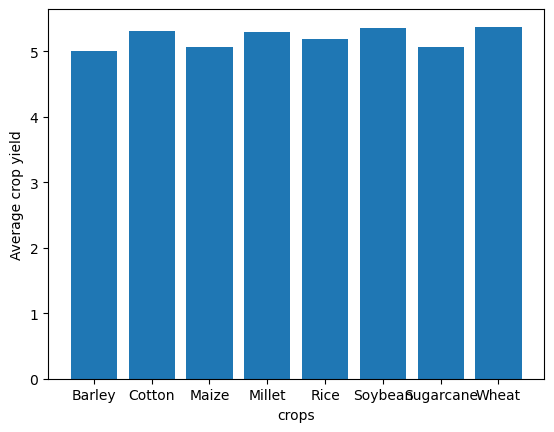

In [41]:
yield_data = df.groupby("Crop")["Yield"].mean()
plt.bar(yield_data.index, yield_data.values)
plt.xlabel("crops")
plt.ylabel("Average crop yield")
# This graph compares the average yield of different crops.

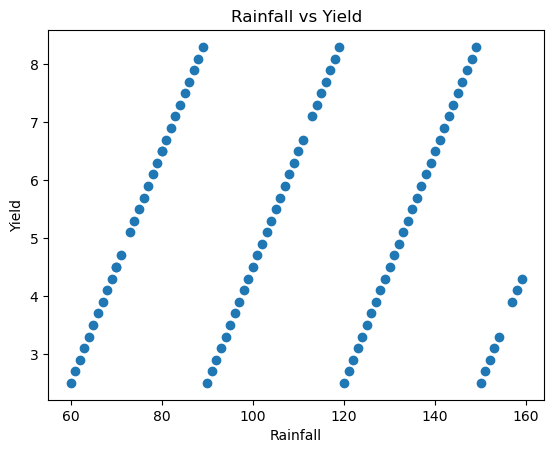

In [5]:
plt.scatter(df["Rainfall"], df["Yield"])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

Text(0, 0.5, 'frequency')

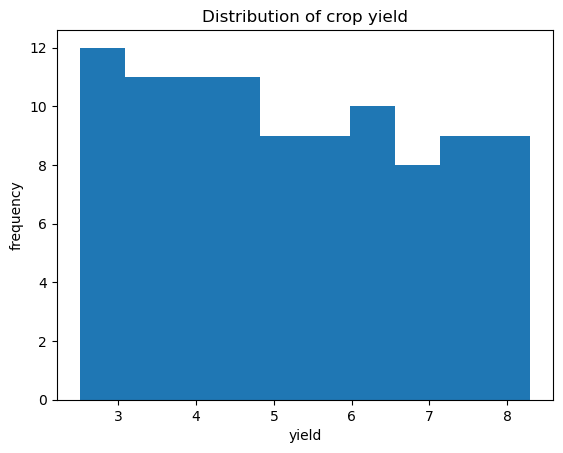

In [56]:
plt.hist(df["Yield"])
plt.title("Distribution of crop yield")
plt.xlabel("yield")
plt.ylabel("frequency")
# The histogram represents the frequency of different crop yield values.
# It helps identify common and less common yield ranges

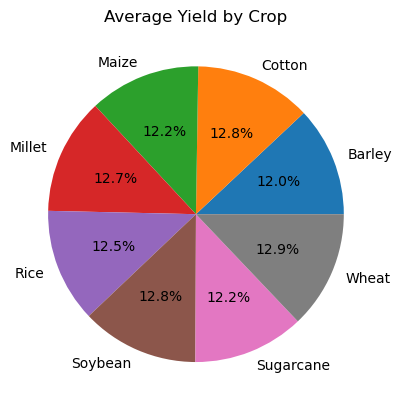

In [55]:
yield_data = df.groupby("Crop")["Yield"].mean()

plt.pie(yield_data, labels=yield_data.index, autopct="%1.1f%%")
plt.title("Average Yield by Crop")
plt.show()
# This graph shows the percentage distribution of average yield among crops.

In [6]:
# Crop Prediction using Decision Tree
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("crop prediction.csv")
# Remove missing values
df = df.dropna()         

# Convert text columns into numbers
crop = LabelEncoder()
soil = LabelEncoder()
region = LabelEncoder()
fertilizer = LabelEncoder()
target = LabelEncoder()

df["Crop"] = crop.fit_transform(df["Crop"])
df["SoilType"] = soil.fit_transform(df["SoilType"])
df["Region"] = region.fit_transform(df["Region"])
df["Fertilizer"] = fertilizer.fit_transform(df["Fertilizer"])
df["Target"] = target.fit_transform(df["Target"])

# Features (Input)
X = df.drop("Target", axis=1)

# Target (Output)
y = df["Target"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42)

# Create the model
model = DecisionTreeClassifier()

# Train the model
model.fit(X_train, y_train)

# Predict the Target
y_pred = model.predict(X_test)

# Convert prediction back to Good/Poor
predicted_result = target.inverse_transform(y_pred)

# Display Prediction
print("Predicted Target:")
print(predicted_result)

# Display Actual Target
actual_result = target.inverse_transform(y_test)

print("\nActual Target:")
print(actual_result)

# Check Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

Predicted Target:
['Good' 'Poor' 'Good' 'Good' 'Good' 'Good' 'Good' 'Poor' 'Poor' 'Poor'
 'Good' 'Good' 'Poor' 'Poor' 'Poor' 'Poor' 'Good' 'Good']

Actual Target:
['Good' 'Poor' 'Good' 'Good' 'Good' 'Good' 'Good' 'Poor' 'Poor' 'Poor'
 'Good' 'Good' 'Poor' 'Poor' 'Poor' 'Poor' 'Good' 'Good']

Accuracy: 1.0


In [9]:
df=pd.read_csv("crop prediction.csv")
df = df.fillna(df.mean(numeric_only=True))
X = df[["Nitrogen", "Phosphorus", "Potassium",
        "Temperature", "Humidity", "pH", "Rainfall"]]
y = df["Yield"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
new_crop = pd.DataFrame({
    "Nitrogen": [90],
    "Phosphorus": [55],
    "Potassium": [45],
    "Temperature": [27.5],
    "Humidity": [70],
    "pH": [6.8],
    "Rainfall": [180]
})
predicted_yield = model.predict(new_crop)

print("Predicted Yield:", round(predicted_yield[0], 2))

Predicted Yield: 9.44
